In [43]:
import pandas as pd
df=pd.read_csv("house_price.csv")
print(df.head())

   area  bedrooms  bathrooms  age  location_score    price
0   650         1          1   20               4  1850000
1   720         2          1   15               5  2150000
2   800         2          1   18               6  2400000
3   850         2          2   10               6  2650000
4   900         2          2   12               7  2900000


In [44]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   area            10 non-null     int64
 1   bedrooms        10 non-null     int64
 2   bathrooms       10 non-null     int64
 3   age             10 non-null     int64
 4   location_score  10 non-null     int64
 5   price           10 non-null     int64
dtypes: int64(6)
memory usage: 608.0 bytes
None
              area   bedrooms  bathrooms       age  location_score  \
count    10.000000  10.000000  10.000000  10.00000       10.000000   
mean    917.000000   2.400000   1.800000  10.70000        6.400000   
std     163.981706   0.699206   0.632456   5.47824        1.264911   
min     650.000000   1.000000   1.000000   4.00000        4.000000   
25%     812.500000   2.000000   1.250000   6.50000        6.000000   
50%     925.000000   2.500000   2.000000   9.50000        6.500000   
75%    1037.50000

In [45]:
x=df[["area","bedrooms","bathrooms","age","location_score"]]
y=df["price"]
print(x.shape)
print(y.shape)

(10, 5)
(10,)


In [46]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)
print("Train Size: ",x_train.shape[0])
print("Test Size: ",x_test.shape[0])

Train Size:  8
Test Size:  2


In [47]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
print("Coefficients: ",model.coef_)
print("Intercept: ",model.intercept_)

Coefficients:  [   6319.21487603 -244576.44628099 -232024.79338843  -19989.66942149
  -74018.59504132]
Intercept:  -1100103.3057851251


In [48]:
y_pred=model.predict(x_test)
print(y_pred[:5])
print(y_test.values[:5])

[4015185.95041322 2058615.70247934]
[3750000 2150000]


In [49]:
from sklearn.metrics import(
    mean_absolute_error,mean_squared_error,r2_score
)
import numpy as np
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_test)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE: ",mae,"MSE: ",mse,"RMSE: ",rmse,"R2:",r2)

MAE:  178285.12396694184 MSE:  0.0 RMSE:  0.0 R2: 0.9385354077110087


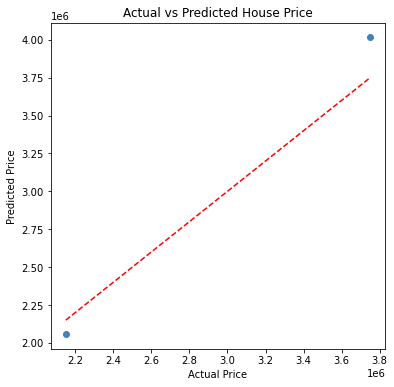

In [67]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred,color="steelblue")
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],"r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()